In [1]:
import math
import numpy as np
import random
import matplotlib.pyplot as plt
from engine import *
from nn import *
from graphviz import Digraph
%matplotlib inline

In [2]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.parents:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ name %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n.op:
            dot.node(name=str(id(n)) + n.op, label=n.op)
            dot.edge(str(id(n)) + n.op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2.op)
    
    return dot

In [3]:
x = Value(5, label='x')
y = Value(5, label='y')
z = x * Value(2)
z.label = 'z'
w = y * z # w = y * x * 2
w.label = 'w'

w.backward()
print('x', x)
print('y', y)
print('z', z)
print('w', w)

x Value(data=5, grad=10, label=x)
y Value(data=5, grad=10, label=y)
z Value(data=10, grad=5, label=z)
w Value(data=50, grad=1, label=w)


In [4]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0, label='x2')

# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.881373, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh()
o.label = 'output'
# print(o)
topo_sort(o)
o.backward()
print(w1,w2)

Value(data=-3.0, grad=1.0000008301711714, label=w1) Value(data=1.0, grad=0.0, label=w2)


relu: Value(data=0, grad=0, label=relu)
e Value(data=1, grad=0, label=e)
d Value(data=-6, grad=0, label=d)
f Value(data=-6, grad=0, label=f)

a Value(data=-2, grad=0, label=a)
b Value(data=3, grad=0, label=b)


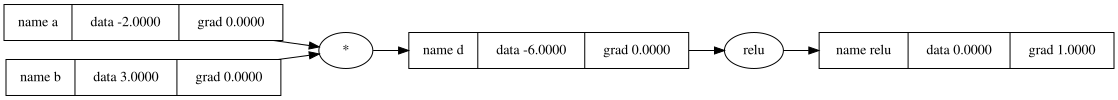

In [5]:
# a = Value(2, label='a')
# o = a + a; o.label = 'a'
# o.backwards()
# a

a = Value(-2, label='a')
b = Value(3, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'
o = d.relu()

o.backward()
print('e', e)
print('d', d)
print('f', f)
print()
print('a', a)
print('b', b)
draw_dot(o)

relu: Value(data=1, grad=0, label=relu)
relu: Value(data=5, grad=0, label=relu)


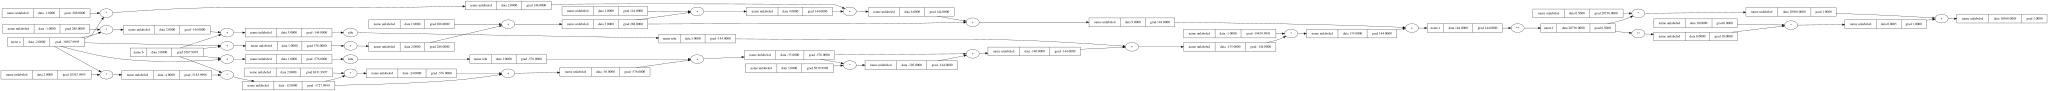

In [6]:
c = a + b
d = a * 2 * b
c = c + c + 1
c += 1 + c + (-a)
d = d + d * 2 + (b + a).relu()
d = d + 3 * d + (b - a).relu()
e = c - d
e.label = 'e'
f = e**2
f.label = 'f'
g = f / 2.0
g = g + 10.0 / f
g.backward()
draw_dot(g)

In [7]:
n = Neuron(2)

[Value(data=-0.06733834564278918, grad=0, label=unlabeled), Value(data=-0.5357755237103419, grad=0, label=unlabeled)] Value(data=-0.09053642129346984, grad=0, label=unlabeled)


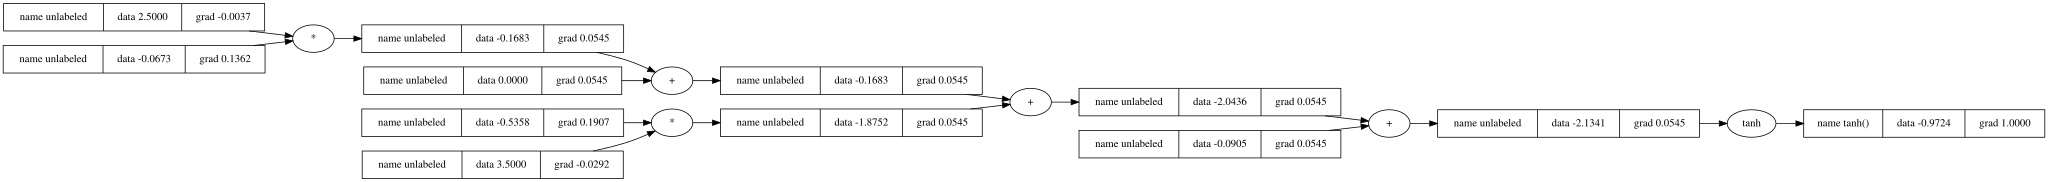

In [8]:
print(n.weights, n.bias)
res = n([2.5, 3.5])
res.backward()
draw_dot(res)

In [19]:
mlp = MLP(3, [4,4,1])
inputs = [[2.0, 3.0, -1.0], [3.0,-1.0,0.5], [0.5,1.0,1.0], [1.0, 1.0, -1.0]]
targets = [1.0,-1.0,-1.0,1.0]

# draw_dot(out)

In [20]:
for _ in range(20):
    out = [mlp(x) for x in inputs]
    losses = [(o-t)**2 for t,o in zip(targets,out)]
    total_loss = sum(losses)
    total_loss.backward()
    mlp.descend(0.05)
print([o.data for o in out])
print(total_loss)

[0.8898112642932706, -0.8963779732522908, -0.8502336208131019, 0.8870843766689318]
Value(data=0.058058988230947815, grad=1, label=unlabeled)


In [26]:
#xor?

mlp = MLP(2, [4,4,1])
inputs = [[0,0], [0,1], [1,0], [1,1]]
targets = [0.0, 1.0, 1.0, 0.0]
for _ in range(2000):
    out = [mlp(x) for x in inputs]
    losses = [(o-t)**2 for t,o in zip(targets,out)]
    total_loss = sum(losses)
    total_loss.backward()
    mlp.descend(0.01)
print([o.data for o in out])
print(total_loss)

# draw_dot(out)

[0.0034350161613258437, 0.9468570551538473, 0.9610935772208762, 0.003346591407819081]
Value(data=0.004360881330468609, grad=1, label=unlabeled)
